# HR Analytics AI System
## Notebook 3: Exploratory Data Analysis (EDA)

In this notebook, we will explore the dataset visually and statistically to uncover
patterns and insights that will guide our machine learning models.

The analysis covers the following areas:

1. Attrition Distribution
2. Attrition by Department
3. Attrition by Gender
4. Attrition by Age Group
5. Monthly Income vs Performance Rating
6. Salary Distribution by Department
7. Overtime vs Attrition
8. Correlation Heatmap

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Initialize Spark Session and Load Data

We initialize the Spark Session and load the preprocessed dataset
from the Parquet file saved in the previous notebook.


In [2]:
spark = SparkSession.builder \
    .appName("HR Analytics - EDA") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# Load preprocessed data
df = spark.read.parquet(
    r"C:\HR-Analytics-AI-System\data\hr_data_preprocessed.parquet"
)

# Load original data for categorical labels
df_original = spark.read.parquet(
    r"C:\HR-Analytics-AI-System\data\hr_data.parquet"
)

print("Data Loaded Successfully.")
print(f"Total Rows: {df.count()}")
print(f"Total Columns: {len(df.columns)}")

Data Loaded Successfully.
Total Rows: 1470
Total Columns: 31


### 2. Attrition Distribution

Attrition refers to employees leaving the company.
Understanding the distribution of attrition is the first step
in identifying patterns and building a predictive model.

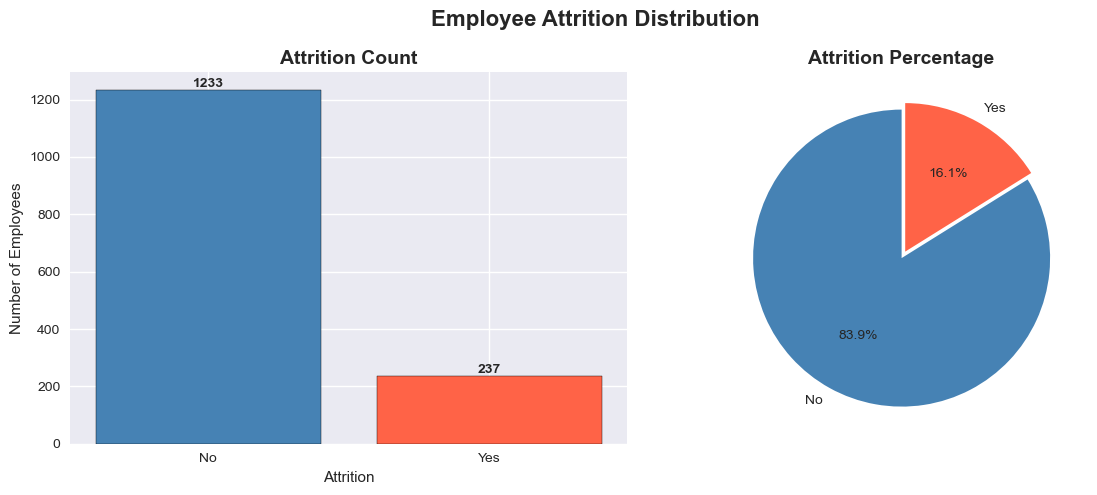

Attrition Distribution:
Attrition  count
       No   1233
      Yes    237


In [3]:
attrition_df = df_original.groupBy("Attrition") \
    .count() \
    .orderBy("count", ascending=False) \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
axes[0].bar(attrition_df["Attrition"], attrition_df["count"], 
            color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Attrition Count", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Number of Employees")
for i, v in enumerate(attrition_df["count"]):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Pie Chart
axes[1].pie(attrition_df["count"], labels=attrition_df["Attrition"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"],
            startangle=90, explode=[0, 0.05])
axes[1].set_title("Attrition Percentage", fontsize=14, fontweight="bold")

plt.suptitle("Employee Attrition Distribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\attrition_distribution.png", dpi=150)
plt.show()
print("Attrition Distribution:")
print(attrition_df.to_string(index=False))

### Attrition Distribution Insights

The dataset reveals a significant class imbalance in attrition:

- 1,233 employees (83.9%) stayed at the company
- 237 employees (16.1%) left the company

This imbalance is important to consider during model building,
as it may cause the model to be biased toward predicting the majority class.
Techniques such as class weighting will be applied during model training
to address this issue.

### 3. Attrition by Department

We analyze attrition rates across different departments to identify
which department has the highest employee turnover.

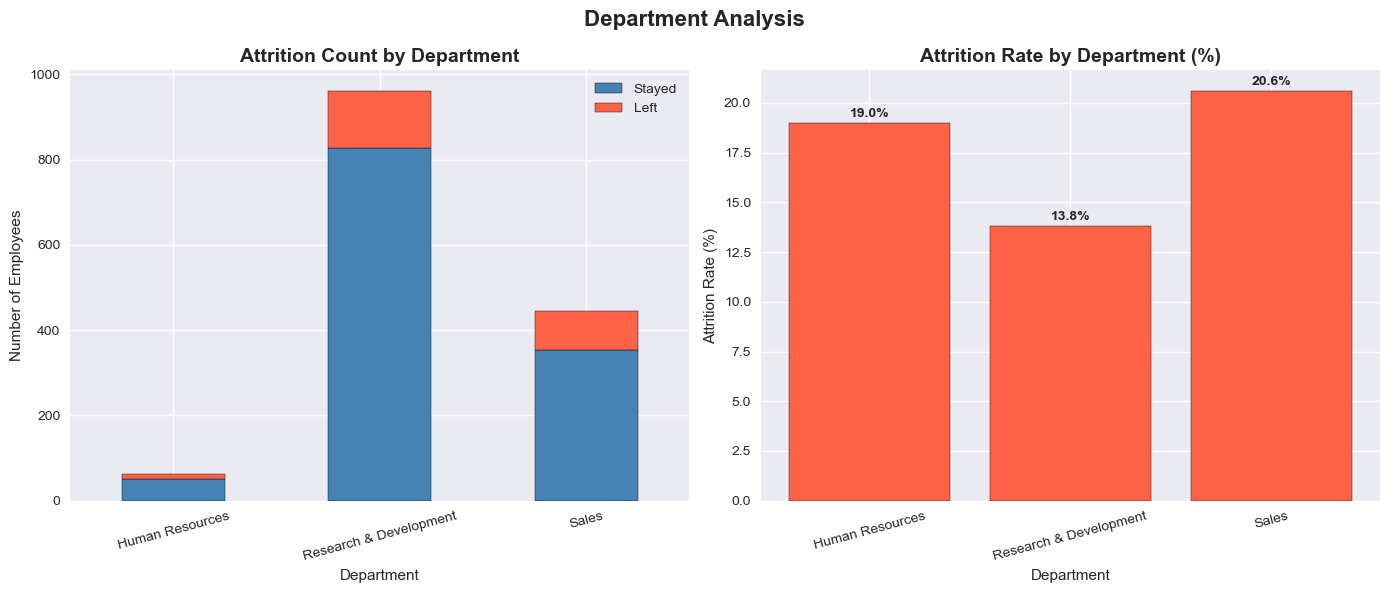

Attrition                No  Yes  Total  Attrition Rate %
Department                                               
Human Resources          51   12     63              19.0
Research & Development  828  133    961              13.8
Sales                   354   92    446              20.6


In [4]:
dept_attrition = df_original.groupBy("Department", "Attrition") \
    .count() \
    .orderBy("Department") \
    .toPandas()

dept_pivot = dept_attrition.pivot(index="Department", columns="Attrition", values="count").fillna(0)
dept_pivot["Total"] = dept_pivot["No"] + dept_pivot["Yes"]
dept_pivot["Attrition Rate %"] = (dept_pivot["Yes"] / dept_pivot["Total"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stacked Bar Chart
dept_pivot[["No", "Yes"]].plot(kind="bar", stacked=True, 
                                color=["steelblue", "tomato"],
                                edgecolor="black", ax=axes[0])
axes[0].set_title("Attrition Count by Department", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Number of Employees")
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(["Stayed", "Left"])

# Attrition Rate
axes[1].bar(dept_pivot.index, dept_pivot["Attrition Rate %"],
            color="tomato", edgecolor="black")
axes[1].set_title("Attrition Rate by Department (%)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("Attrition Rate (%)")
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(dept_pivot["Attrition Rate %"]):
    axes[1].text(i, v + 0.3, f"{v}%", ha="center", fontweight="bold")

plt.suptitle("Department Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\attrition_by_department.png", dpi=150)
plt.show()
print(dept_pivot[["No", "Yes", "Total", "Attrition Rate %"]].to_string())

### Department Analysis Insights

The analysis reveals clear differences in attrition rates across departments:

- **Sales** has the highest attrition rate at 20.6%, suggesting potential issues
  with job satisfaction, compensation, or work pressure in this department
- **Human Resources** follows with a 19.0% attrition rate
- **Research & Development** has the lowest attrition rate at 13.8%,
  indicating relatively higher employee satisfaction in this department

These findings suggest that HR strategies should focus primarily on
the Sales and Human Resources departments to reduce employee turnover.

### 4. Attrition by Gender

We analyze whether gender has any influence on employee attrition rates.

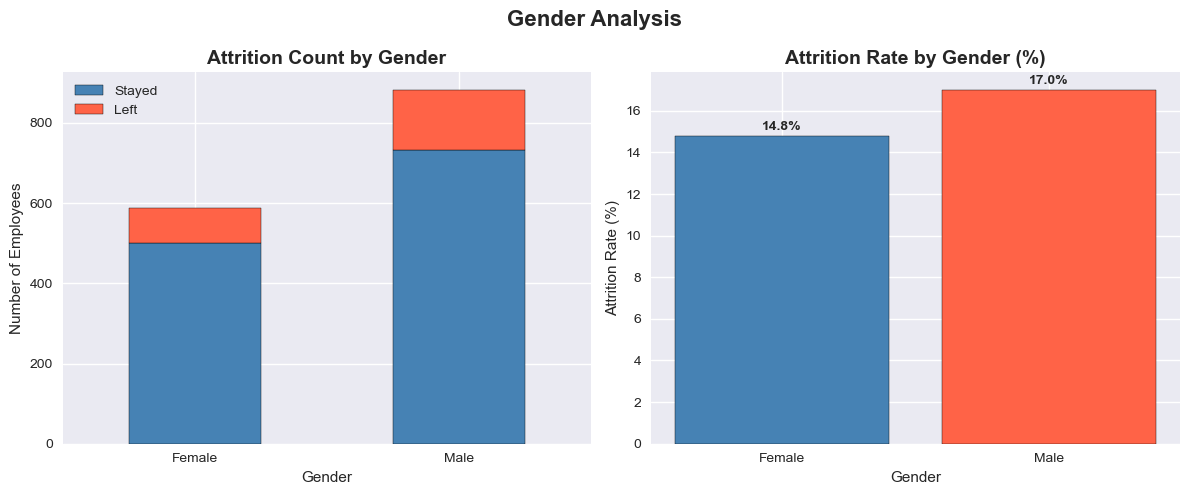

Attrition   No  Yes  Total  Attrition Rate %
Gender                                      
Female     501   87    588              14.8
Male       732  150    882              17.0


In [5]:
gender_attrition = df_original.groupBy("Gender", "Attrition") \
    .count() \
    .orderBy("Gender") \
    .toPandas()

gender_pivot = gender_attrition.pivot(index="Gender", columns="Attrition", values="count").fillna(0)
gender_pivot["Total"] = gender_pivot["No"] + gender_pivot["Yes"]
gender_pivot["Attrition Rate %"] = (gender_pivot["Yes"] / gender_pivot["Total"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stacked Bar Chart
gender_pivot[["No", "Yes"]].plot(kind="bar", stacked=True,
                                  color=["steelblue", "tomato"],
                                  edgecolor="black", ax=axes[0])
axes[0].set_title("Attrition Count by Gender", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Number of Employees")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(["Stayed", "Left"])

# Attrition Rate
axes[1].bar(gender_pivot.index, gender_pivot["Attrition Rate %"],
            color=["steelblue", "tomato"], edgecolor="black")
axes[1].set_title("Attrition Rate by Gender (%)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Attrition Rate (%)")
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(gender_pivot["Attrition Rate %"]):
    axes[1].text(i, v + 0.3, f"{v}%", ha="center", fontweight="bold")

plt.suptitle("Gender Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\attrition_by_gender.png", dpi=150)
plt.show()
print(gender_pivot[["No", "Yes", "Total", "Attrition Rate %"]].to_string())

### Gender Analysis Insights

The analysis shows a moderate difference in attrition rates between genders:

- **Male** employees have a higher attrition rate at 17.0% (150 out of 882)
- **Female** employees have a lower attrition rate at 14.8% (87 out of 588)

While the difference is not dramatic, it suggests that male employees
are slightly more likely to leave the company than female employees.
This could be related to differences in job roles, compensation,
or career growth opportunities between genders.

### 5. Attrition by Age Group

We analyze attrition across different age groups to identify
which age range has the highest employee turnover.

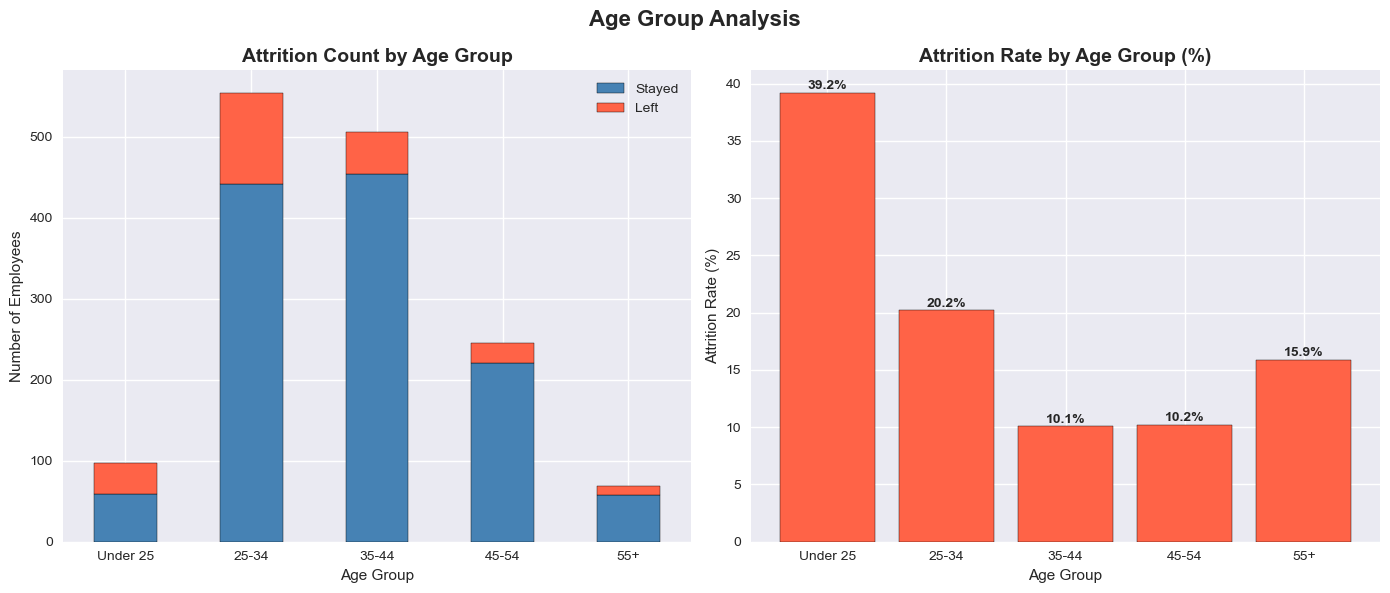

Attrition   No  Yes  Total  Attrition Rate %
AgeGroup                                    
Under 25    59   38     97              39.2
25-34      442  112    554              20.2
35-44      454   51    505              10.1
45-54      220   25    245              10.2
55+         58   11     69              15.9


In [6]:
df_age = df_original.withColumn("AgeGroup",
    F.when(F.col("Age") < 25, "Under 25")
     .when((F.col("Age") >= 25) & (F.col("Age") < 35), "25-34")
     .when((F.col("Age") >= 35) & (F.col("Age") < 45), "35-44")
     .when((F.col("Age") >= 45) & (F.col("Age") < 55), "45-54")
     .otherwise("55+")
)

age_attrition = df_age.groupBy("AgeGroup", "Attrition") \
    .count() \
    .orderBy("AgeGroup") \
    .toPandas()

age_pivot = age_attrition.pivot(index="AgeGroup", columns="Attrition", values="count").fillna(0)
age_pivot["Total"] = age_pivot["No"] + age_pivot["Yes"]
age_pivot["Attrition Rate %"] = (age_pivot["Yes"] / age_pivot["Total"] * 100).round(1)
age_pivot = age_pivot.reindex(["Under 25", "25-34", "35-44", "45-54", "55+"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stacked Bar Chart
age_pivot[["No", "Yes"]].plot(kind="bar", stacked=True,
                               color=["steelblue", "tomato"],
                               edgecolor="black", ax=axes[0])
axes[0].set_title("Attrition Count by Age Group", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Employees")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(["Stayed", "Left"])

# Attrition Rate
axes[1].bar(age_pivot.index, age_pivot["Attrition Rate %"],
            color="tomato", edgecolor="black")
axes[1].set_title("Attrition Rate by Age Group (%)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Attrition Rate (%)")
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(age_pivot["Attrition Rate %"]):
    axes[1].text(i, v + 0.3, f"{v}%", ha="center", fontweight="bold")

plt.suptitle("Age Group Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\attrition_by_age.png", dpi=150)
plt.show()
print(age_pivot[["No", "Yes", "Total", "Attrition Rate %"]].to_string())

### Age Group Analysis Insights

The analysis reveals a clear trend between age and attrition:

- **Under 25** has the highest attrition rate at 39.2%, which is significantly higher
  than all other age groups. Young employees are more likely to leave,
  possibly due to limited career growth opportunities or better offers elsewhere
- **25-34** follows with a 20.2% attrition rate, still relatively high
- **35-44** and **45-54** have the lowest attrition rates at 10.1% and 10.2%,
  suggesting that mid-career employees are more stable and committed
- **55+** shows a slightly higher rate at 15.9%, possibly due to early retirement

This finding highlights the importance of investing in retention strategies
specifically targeting younger employees in the early stages of their careers.

### 6. Monthly Income vs Performance Rating

We analyze the relationship between monthly income and performance rating
to understand whether higher-performing employees are compensated accordingly.

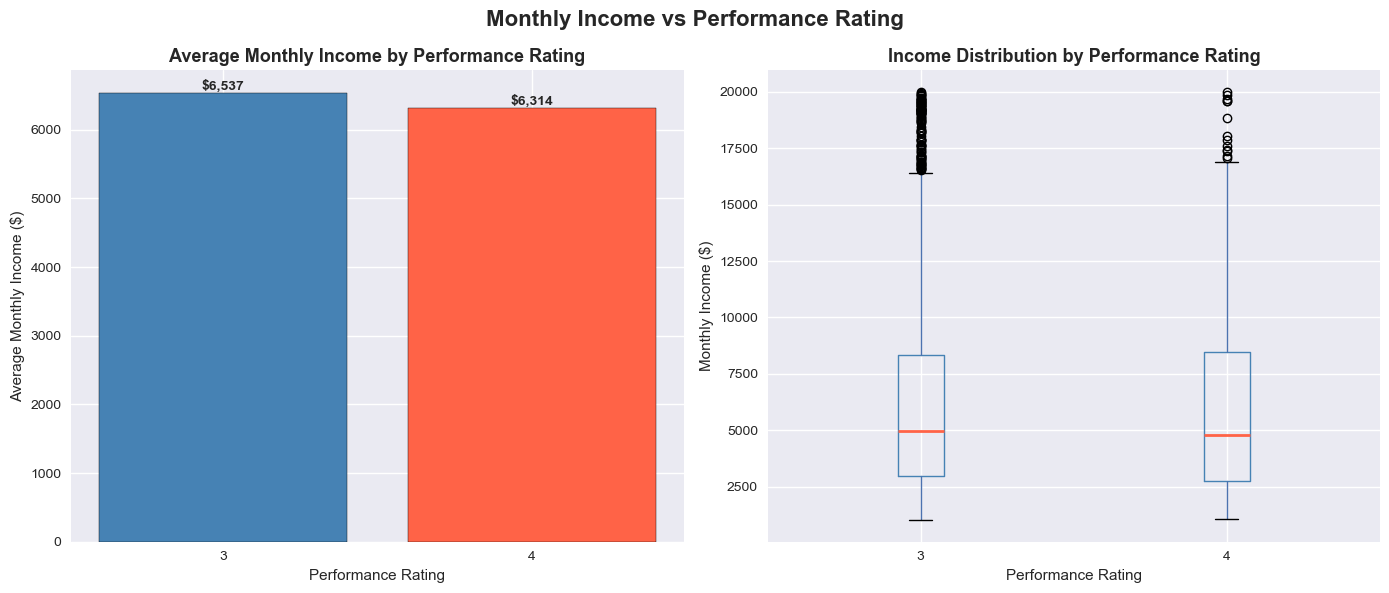

 PerformanceRating  Avg Income  Min Income  Max Income  Employee Count
                 3     6537.27        1009       19999            1244
                 4     6313.89        1052       19973             226


In [7]:
income_perf = df_original.groupBy("PerformanceRating") \
    .agg(
        F.round(F.avg("MonthlyIncome"), 2).alias("Avg Income"),
        F.round(F.min("MonthlyIncome"), 2).alias("Min Income"),
        F.round(F.max("MonthlyIncome"), 2).alias("Max Income"),
        F.count("*").alias("Employee Count")
    ) \
    .orderBy("PerformanceRating") \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average Income by Performance Rating
axes[0].bar(income_perf["PerformanceRating"].astype(str),
            income_perf["Avg Income"],
            color=["steelblue", "tomato"],
            edgecolor="black")
axes[0].set_title("Average Monthly Income by Performance Rating",
                   fontsize=13, fontweight="bold")
axes[0].set_xlabel("Performance Rating")
axes[0].set_ylabel("Average Monthly Income ($)")
for i, v in enumerate(income_perf["Avg Income"]):
    axes[0].text(i, v + 50, f"${v:,.0f}", ha="center", fontweight="bold")

# Box Plot
income_pdf = df_original.select("PerformanceRating", "MonthlyIncome").toPandas()
income_pdf.boxplot(column="MonthlyIncome", by="PerformanceRating", ax=axes[1],
                   boxprops=dict(color="steelblue"),
                   medianprops=dict(color="tomato", linewidth=2))
axes[1].set_title("Income Distribution by Performance Rating",
                   fontsize=13, fontweight="bold")
axes[1].set_xlabel("Performance Rating")
axes[1].set_ylabel("Monthly Income ($)")
plt.suptitle("Monthly Income vs Performance Rating", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\income_vs_performance.png", dpi=150)
plt.show()
print(income_perf.to_string(index=False))

### Monthly Income vs Performance Rating Insights

The analysis reveals a surprising finding regarding income and performance:

- Employees with **Performance Rating 3** earn a slightly higher average income
  of $6,537 compared to those with Rating 4 who earn $6,314
- This suggests that higher performance does not necessarily lead to higher compensation
  in this organization, which could be a contributing factor to employee attrition
- The box plots show a similar income distribution for both rating groups,
  with a wide range from approximately $1,000 to $20,000
- The dataset only contains two performance ratings (3 and 4),
  indicating that all employees are rated as either "Excellent" or "Outstanding"

This finding suggests that the company may need to review its compensation strategy
to better reward high-performing employees and reduce attrition risk.

### 7. Salary Distribution by Department

We analyze how monthly income is distributed across different departments
to identify any compensation disparities that may contribute to attrition.

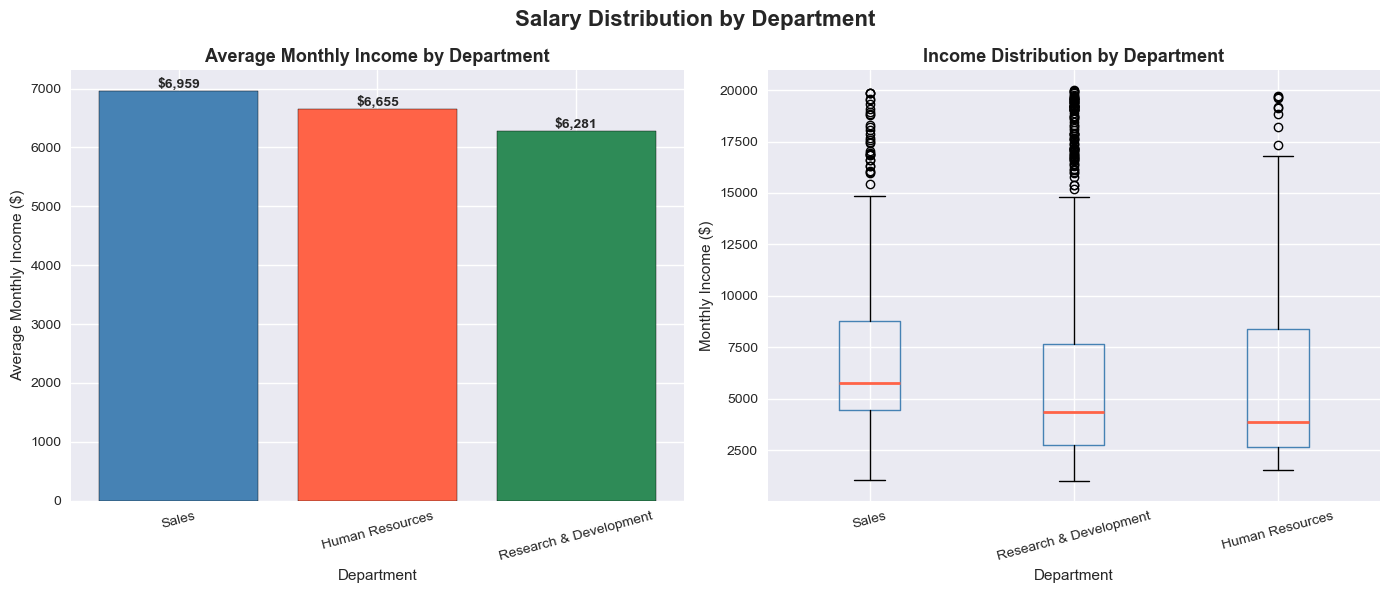

            Department  Avg Income  Min Income  Max Income  Employee Count
                 Sales     6959.17        1052       19847             446
       Human Resources     6654.51        1555       19717              63
Research & Development     6281.25        1009       19999             961


In [8]:
salary_dept = df_original.groupBy("Department") \
    .agg(
        F.round(F.avg("MonthlyIncome"), 2).alias("Avg Income"),
        F.round(F.min("MonthlyIncome"), 2).alias("Min Income"),
        F.round(F.max("MonthlyIncome"), 2).alias("Max Income"),
        F.count("*").alias("Employee Count")
    ) \
    .orderBy("Avg Income", ascending=False) \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average Income by Department
axes[0].bar(salary_dept["Department"],
            salary_dept["Avg Income"],
            color=["steelblue", "tomato", "seagreen"],
            edgecolor="black")
axes[0].set_title("Average Monthly Income by Department",
                   fontsize=13, fontweight="bold")
axes[0].set_xlabel("Department")
axes[0].set_ylabel("Average Monthly Income ($)")
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(salary_dept["Avg Income"]):
    axes[0].text(i, v + 50, f"${v:,.0f}", ha="center", fontweight="bold")

# Box Plot
salary_pdf = df_original.select("Department", "MonthlyIncome").toPandas()
departments = salary_pdf["Department"].unique()
data_to_plot = [salary_pdf[salary_pdf["Department"] == dept]["MonthlyIncome"].values
                for dept in departments]
axes[1].boxplot(data_to_plot, labels=departments,
                boxprops=dict(color="steelblue"),
                medianprops=dict(color="tomato", linewidth=2))
axes[1].set_title("Income Distribution by Department",
                   fontsize=13, fontweight="bold")
axes[1].set_xlabel("Department")
axes[1].set_ylabel("Monthly Income ($)")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Salary Distribution by Department", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\salary_by_department.png", dpi=150)
plt.show()
print(salary_dept.to_string(index=False))

### Salary Distribution by Department Insights

The analysis reveals clear compensation differences across departments:

- **Sales** has the highest average monthly income at $6,959, yet it also has
  the highest attrition rate at 20.6%, suggesting that salary alone is not
  sufficient to retain employees in this department
- **Human Resources** follows with an average of $6,655 per month
- **Research & Development** has the lowest average income at $6,281,
  yet it maintains the lowest attrition rate at 13.8%

This finding indicates that factors beyond compensation, such as job satisfaction,
work environment, and career growth opportunities, play a significant role
in employee retention across departments.

### 8. Overtime vs Attrition

We analyze the relationship between working overtime and employee attrition
to determine whether overworked employees are more likely to leave the company.

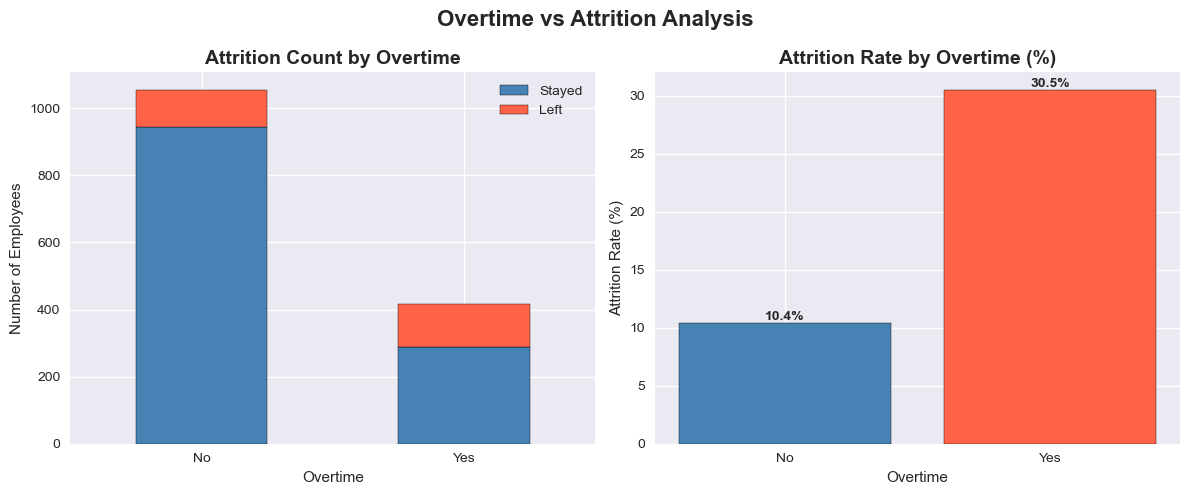

Attrition   No  Yes  Total  Attrition Rate %
OverTime                                    
No         944  110   1054              10.4
Yes        289  127    416              30.5


In [9]:
overtime_attrition = df_original.groupBy("OverTime", "Attrition") \
    .count() \
    .orderBy("OverTime") \
    .toPandas()

overtime_pivot = overtime_attrition.pivot(index="OverTime", columns="Attrition", values="count").fillna(0)
overtime_pivot["Total"] = overtime_pivot["No"] + overtime_pivot["Yes"]
overtime_pivot["Attrition Rate %"] = (overtime_pivot["Yes"] / overtime_pivot["Total"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stacked Bar Chart
overtime_pivot[["No", "Yes"]].plot(kind="bar", stacked=True,
                                    color=["steelblue", "tomato"],
                                    edgecolor="black", ax=axes[0])
axes[0].set_title("Attrition Count by Overtime", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Overtime")
axes[0].set_ylabel("Number of Employees")
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(["Stayed", "Left"])

# Attrition Rate
axes[1].bar(overtime_pivot.index, overtime_pivot["Attrition Rate %"],
            color=["steelblue", "tomato"], edgecolor="black")
axes[1].set_title("Attrition Rate by Overtime (%)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Overtime")
axes[1].set_ylabel("Attrition Rate (%)")
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(overtime_pivot["Attrition Rate %"]):
    axes[1].text(i, v + 0.3, f"{v}%", ha="center", fontweight="bold")

plt.suptitle("Overtime vs Attrition Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\overtime_vs_attrition.png", dpi=150)
plt.show()
print(overtime_pivot[["No", "Yes", "Total", "Attrition Rate %"]].to_string())

### Overtime vs Attrition Insights

The analysis reveals one of the strongest relationships found in the dataset:

- Employees who work **overtime** have an attrition rate of **30.5%**,
  which is nearly three times higher than those who do not work overtime
- Employees who do **not work overtime** have a significantly lower attrition rate of **10.4%**

This is one of the most significant predictors of employee attrition in this dataset.
Overworked employees are clearly at a much higher risk of leaving the company.
This finding strongly suggests that the company should review its overtime policies
and workload distribution to improve employee retention.

### 9. Correlation Heatmap

A correlation heatmap shows the relationship between all numerical features.
Values close to 1 indicate a strong positive correlation,
values close to -1 indicate a strong negative correlation,
and values close to 0 indicate no correlation.

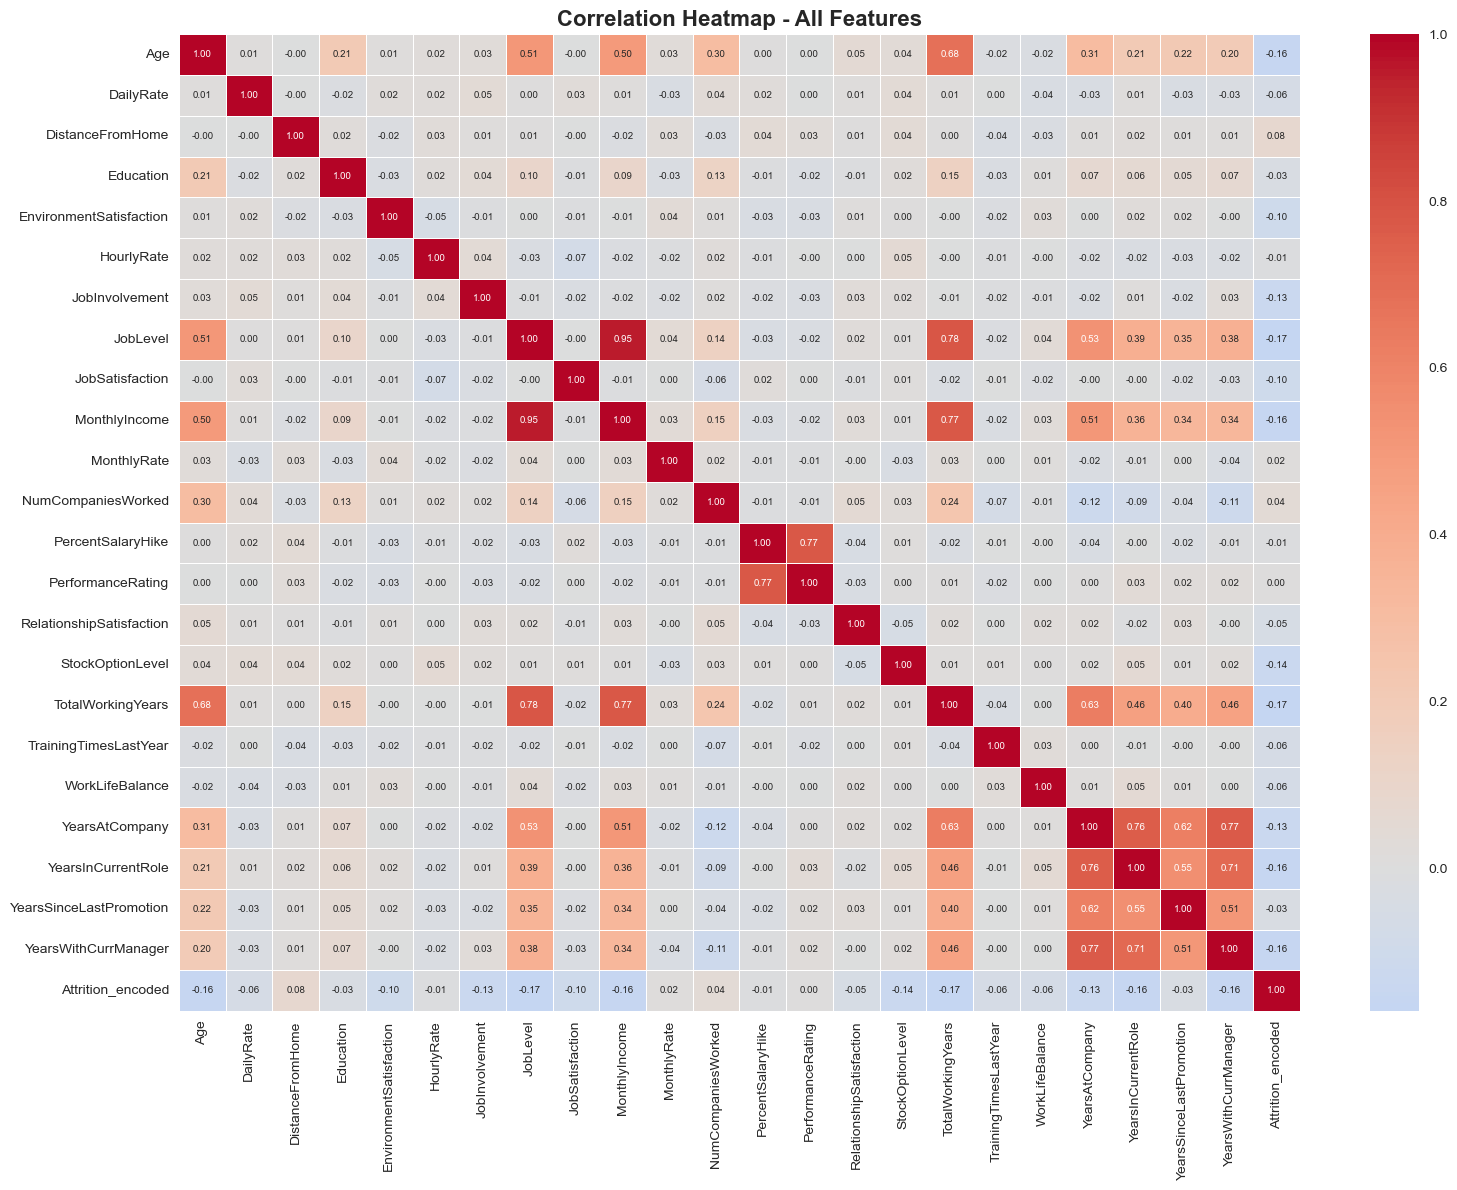

Top Correlations with Attrition:
----------------------------------------
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063


In [10]:
numeric_cols = [
    "Age", "DailyRate", "DistanceFromHome", "Education",
    "EnvironmentSatisfaction", "HourlyRate", "JobInvolvement",
    "JobLevel", "JobSatisfaction", "MonthlyIncome", "MonthlyRate",
    "NumCompaniesWorked", "PercentSalaryHike", "PerformanceRating",
    "RelationshipSatisfaction", "StockOptionLevel", "TotalWorkingYears",
    "TrainingTimesLastYear", "WorkLifeBalance", "YearsAtCompany",
    "YearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager",
    "Attrition_encoded"
]

corr_pdf = df.select(numeric_cols).toPandas()
corr_matrix = corr_pdf.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            linewidths=0.5,
            annot_kws={"size": 7})
plt.title("Correlation Heatmap - All Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\HR-Analytics-AI-System\outputs\correlation_heatmap.png", dpi=150)
plt.show()

# Top correlations with Attrition
print("Top Correlations with Attrition:")
print("-" * 40)
attrition_corr = corr_matrix["Attrition_encoded"].drop("Attrition_encoded") \
    .sort_values(ascending=False)
print(attrition_corr.to_string())

### Correlation Heatmap Insights

The correlation analysis reveals the following key relationships with Attrition:

**Positive Correlations (higher value = more attrition):**
- **DistanceFromHome** (0.08): Employees living farther from work are slightly
  more likely to leave
- **NumCompaniesWorked** (0.04): Employees who have worked at more companies
  tend to have higher attrition

**Negative Correlations (higher value = less attrition):**
- **TotalWorkingYears** (-0.17): More experienced employees are less likely to leave
- **JobLevel** (-0.17): Higher job levels are associated with lower attrition
- **YearsInCurrentRole** (-0.16): Employees in their role longer tend to stay
- **MonthlyIncome** (-0.16): Higher income is associated with lower attrition
- **Age** (-0.16): Older employees are less likely to leave
- **StockOptionLevel** (-0.14): Employees with stock options tend to stay longer
- **JobInvolvement** (-0.13): More engaged employees are less likely to leave

These correlations will guide our feature selection during model building.

### 10. Summary

In this notebook, we successfully completed the Exploratory Data Analysis phase.
The key findings are summarized below:

1. **Attrition Distribution:** 16.1% of employees left the company, indicating a class imbalance that must be addressed during model training
2. **Department:** Sales has the highest attrition rate at 20.6%, followed by Human Resources at 19.0%
3. **Gender:** Male employees have a slightly higher attrition rate at 17.0% compared to 14.8% for females
4. **Age:** Younger employees under 25 have the highest attrition rate at 39.2%, decreasing significantly with age
5. **Income vs Performance:** Higher performance does not necessarily lead to higher compensation, which may contribute to attrition
6. **Salary by Department:** Sales employees earn the most but still have the highest attrition rate
7. **Overtime:** Employees working overtime have an attrition rate of 30.5%, nearly three times higher than those who do not
8. **Correlation:** TotalWorkingYears, JobLevel, MonthlyIncome, and Age are the strongest negative predictors of attrition

The dataset is now ready for the next phase: Feature Engineering.